Corporate Bankruptcy and the 2008 Financial Crisis

This project analyzes which financial variables are most associated with corporate bankruptcy and whether those relationships change before and after the 2008 financial crisis.

While bankruptcy is often explained through individual firm failures, this project takes a broader approach by analyzing over 78,000 company-year observations from publicly traded U.S. firms between 1999 and 2018.

Using a Random Forest model, I identified which financial variables are most important in predicting bankruptcy and examine how those patterns shift across time.

The results suggest that bankruptcy is consistently driven by multiple financial factors, but the relative importance of performance and market-based indicators increases after 2008, pointing to a shift in how financial risk is evaluated.

Data and Methodology

The dataset consists of financial information from publicly traded U.S. companies, with each row representing a firm in a given year. Key variables include measures of profitability, firm size, and financial structure, such as revenue, assets, liabilities, and market value.

To analyze the data, I use a Random Forest model. This approach allows me to capture complex relationships between variables and extract feature importance scores, which indicate how influential each variable is in predicting bankruptcy.

The goal is not only to predict bankruptcy, but to understand which financial factors are most associated with firm failure.

Model Setup

I selected a set of financial variables that capture firm performance, size, and debt structure while taking away unnecessary or reptitive columns. The dataset is split into training and testing sets to evaluate the model. The Random Forest model is then trained to identify patterns associated with bankruptcy outcomes.

In [3]:
# load and clean data 
import pandas as pd

df = pd.read_csv("../data/american_bankruptcy.csv")

# keep only columns relevant to bankruptcy (profitability, size, debt, liquidity)
df = df[[
    "status_label", "year", "X1", "X4", "X6", "X8", "X10",
    "X11", "X12", "X14", "X16", "X17"
]]

# rename columns to make them readable and easier to work with later
df = df.rename(columns={
    "X1": "current_assets",
    "X4": "ebitda",
    "X6": "net_income",
    "X8": "market_value",
    "X10": "total_assets",
    "X11": "long_term_debt",
    "X12": "ebit",
    "X14": "current_liabilities",
    "X16": "total_revenue",
    "X17": "total_liabilities"
})

# convert target variable into binary (0 = alive, 1 = bankrupt)
# needed because machine learning models require numeric labels
df["status_label"] = df["status_label"].replace({
    "alive": 0,
    "failed": 1
})

# make column numeric only
df["status_label"] = df["status_label"].astype(int)

# save cleaned file
df.to_csv("../data/bankruptcy_clean.csv", index=False)

df.head()


,status_label,year,current_assets,ebitda,net_income,market_value,total_assets,long_term_debt,ebit,current_liabilities,total_revenue,total_liabilities
0,0,1999,511.267,89.031,35.163,372.7519,740.998,180.447,70.658,163.816,1024.333,401.483
1,0,2000,485.856,64.367,18.531,377.1180,701.854,179.987,45.790,125.392,874.255,361.642
2,0,2001,436.656,27.207,-58.939,364.5928,710.199,217.699,4.711,150.464,638.721,399.964
3,0,2002,396.412,30.745,-12.410,143.3295,686.621,164.658,3.573,203.575,606.337,391.633
4,0,2003,432.204,47.491,3.504,308.9071,709.292,248.666,20.811,131.261,651.958,407.608


In [4]:
# run Random Forest
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

features = [
    "current_assets",
    "ebitda",
    "net_income",
    "market_value",
    "total_assets",
    "long_term_debt",
    "ebit",
    "current_liabilities",
    "total_revenue",
    "total_liabilities"
]

# separate inputs (X) and target (y)
X = df[features]
y = df["status_label"]

# split data into training and testing sets to evaluate model performance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Random Forest captures nonlinear relationships and provides feature importance for interpretation
model = RandomForestClassifier()
model.fit(X_train, y_train)

print("Model ran successfully")


Model ran successfully


In [5]:
# show feature importance
importance_df = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
})


# sort features from most to least important for easier interpretation
importance_df = importance_df.sort_values("importance", ascending=False)
print(importance_df)

               feature  importance
3         market_value    0.110926
8        total_revenue    0.108557
0       current_assets    0.104719
9    total_liabilities    0.101243
4         total_assets    0.100349
7  current_liabilities    0.098045
2           net_income    0.097006
1               ebitda    0.096999
6                 ebit    0.095795
5       long_term_debt    0.086360


What Drives Bankruptcy?

To understand which variables matter most, I examined feature importance scores from the model. These scores indicated how much each variable contributes to predicting bankruptcy.

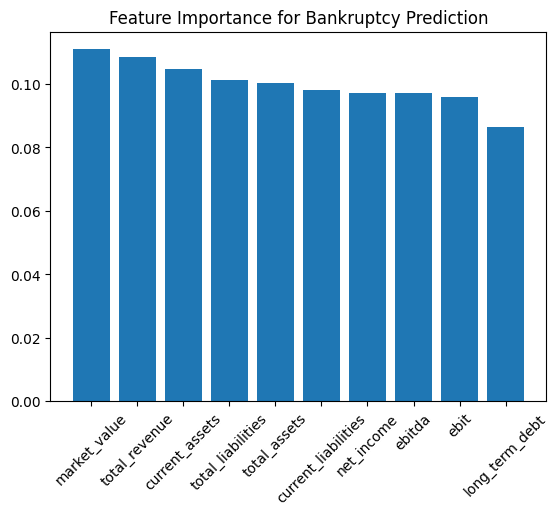

In [6]:
# make chart
import matplotlib.pyplot as plt

# visualize feature importance to compare the relative impact of each variable
# higher importance means the variable plays a larger role in the model’s decision-making
plt.bar(importance_df["feature"], importance_df["importance"])
plt.xticks(rotation=45)
plt.title("Feature Importance for Bankruptcy Prediction")
plt.show()

The feature importance results show that no single variable dominates bankruptcy prediction. Instead, factors such as market value, total revenue, and liabilities all contribute at similar levels. This suggests that bankruptcy is driven by a combination of firm size, financial performance, and debt structure rather than a single indicator.

These variables reflect broader economic realities about how firms operate and survive. For example, market value captures investor confidence and expectations about a firm’s future, while revenue and assets reflect the scale of a company’s operations.

As a result, the model is not predicting bankruptcy from isolated metrics, but from a combination of how firms perform internally and how they are perceived externally.

Did the 2008 Financial Crisis Change Bankruptcy Risk?

The 2008 financial crisis was a global economic collapse triggered by the housing market crash and failures of major financial institutions, making it a natural breakpoint for analyzing changes in bankruptcy risk.

To examine this, I split the dataset into pre-2008 and post-2008 periods and run the same model on each subset.

In [7]:
# compare pre and post 2008 to see if bankruptcy drivers change across economic periods
df_pre = df[df["year"] < 2008]
df_post = df[df["year"] >= 2008]

# pre 2008
X_pre = df_pre[features]
y_pre = df_pre["status_label"]

model_pre = RandomForestClassifier()
model_pre.fit(X_pre, y_pre)

# store feature importance for pre-2008
pre_df = pd.DataFrame({
    "feature": features,
    "importance_pre": model_pre.feature_importances_
})

# post 2008
X_post = df_post[features]
y_post = df_post["status_label"]

model_post = RandomForestClassifier()
model_post.fit(X_post, y_post)

# store feature importance for post-2008
post_df = pd.DataFrame({
    "feature": features,
    "importance_post": model_post.feature_importances_
})


               feature  importance_pre  importance_post
0       current_assets        0.105865         0.099397
1               ebitda        0.094883         0.095082
2           net_income        0.095648         0.100734
3         market_value        0.106123         0.128594
4         total_assets        0.103451         0.097501
5       long_term_debt        0.088857         0.083454
6                 ebit        0.091771         0.095349
7  current_liabilities        0.098335         0.093630
8        total_revenue        0.113467         0.104341
9    total_liabilities        0.101600         0.101916


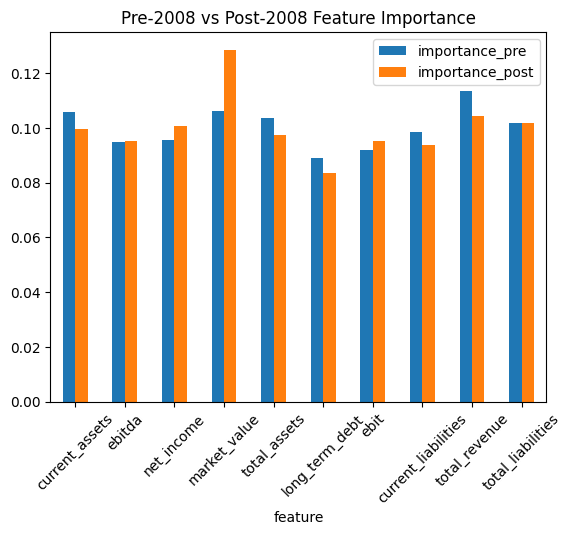

In [8]:
# merge results to directly compare how importance changes over time
comparison = pd.merge(pre_df, post_df, on="feature")
print(comparison)

# visualize differences between periods
comparison.plot(x="feature", y=["importance_pre", "importance_post"], kind="bar")
plt.xticks(rotation=45)
plt.title("Pre-2008 vs Post-2008 Feature Importance")
plt.show()

Comparing pre- and post-2008 results shows small but noticeable changes. Market value and net income became slightly more important after 2008, while long-term debt became slightly less important. This suggests that after the financial crisis, bankruptcy risk may have been more tied to firm performance and market perception than just debt levels.

While the Random Forest model identifies which variables are most important, it does not directly explain why they matter. Instead, it detects patterns in how combinations of variables relate to bankruptcy outcomes.

The results suggest that variables tied to firm scale and market perception, such as market value and total revenue, consistently rank among the most important predictors. At the same time, variables related to financial health, such as net income and liabilities, also play a significant role, reinforcing that bankruptcy is influenced by both performance and debt structure.

Importantly, no single variable dominates the model. This reflects the reality that no one factor alone can cause a company to fail, but rather the interaction of multiple financial pressures over time are what lead to bankruptcy.

The shift in feature importance after 2008 suggests a change in how financial risk is evaluated. The increased importance of market value and net income may reflect a post-crisis environment in which investors and institutions placed greater emphasis on performance and valuation metrics.

This shift can be understood in the context of the financial crisis, which exposed weaknesses in relying too heavily on debt structures and balance sheet indicators alone. As a result, measures tied to market perception and firm performance may have become more central in assessing financial stability.

In [10]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)

lr_accuracy = model_lr.score(X_test, y_test)
rf_accuracy = model.score(X_test, y_test)

print("Random Forest Accuracy:", rf_accuracy)
print("Logistic Regression Accuracy:", lr_accuracy)

Random Forest Accuracy: 0.9376628328143864
Logistic Regression Accuracy: 0.935692952913516


To test whether the results depend on model complexity, I also ran a logistic regression model. The accuracy is similar to the Random Forest model, suggesting that the relationships between financial variables and bankruptcy are not entirely dependent on complex nonlinear interactions.

This reinforces the idea that while Random Forest helps identify variable importance, the underlying relationships are still grounded in interpretable financial patterns.

This dataset only includes publicly traded companies, which excludes smaller private firms and may bias the results toward larger organizations. Additionally, bankruptcy is treated as a binary outcome, which does not capture varying degrees of financial distress.

The model reflects patterns in historical financial data and does not account for external factors such as industry differences or broader macroeconomic shocks beyond the 2008 crisis. As a result, the findings should be interpreted as patterns within the dataset rather than definitive causal relationships.

The findings align with a broader understanding in economic history that the failure of a company is rarely the result of a single shock. Instead, bankruptcy tends to occur when multiple pressures, such as declining profitability, high liabilities, and weakening market confidence, converge over time.

The relatively even distribution of feature importance supports this idea, suggesting that no single factor dominates. This reinforces the view that firm failures are systemic rather than isolated, shaped by interactions between conditions of the firm and larger economic environments.

Although Random Forest provides a ranking of feature importance, it does not explain how or why these variables interact to produce bankruptcy outcomes. For instance, it cannot determine whether low revenue directly causes bankruptcy or whether both are outcomes of deeper structural issues.

This limitation is important from a historical perspective. The model identifies patterns in the data, but those patterns are shaped by broader economic forces that the model itself cannot observe. It should therefore be understood as a tool for identifying relationships rather than explaining causation.

This computational approach allows for the analysis of thousands of firms simultaneously, revealing patterns that would be difficult to identify through traditional qualitative methods alone. However, it also abstracts away important details about individual firms, industries, and historical context.

Overall, this analysis shows that companies go bankrupt due to multiple financial factors rather than one dominant variable. The 2008 financial crisis, a global economic collapse triggered by the housing market crash and failures of major financial institutions, serves as a natural breakpoint for changes in bankruptcy risk. While the relative importance of financial variables is fairly stable, there are small shifts after 2008 that suggest broader economic conditions can influence which factors matter most. This highlights that bankruptcy risk is not only firm-specific but also shaped by the economic environment.